In [ ]:
import pandas as pd
import numpy as np

In [ ]:
num_users = 5000

In [ ]:
user_id = np.arange(1, num_users+1)

In [ ]:
countries = ['US', 'UK', 'IN']
country_probs = [0.33, 0.31, 0.36]
country = np.random.choice(countries, size = num_users, p=country_probs)

In [ ]:
devices = ['Mobile', 'Desktop', 'Tablet']
device_probs = [0.65, 0.30, 0.05]
device = np.random.choice(devices, size = num_users, p=device_probs)

In [ ]:
date_range = pd.date_range(start='2025-10-01', end='2026-03-31')

# create increasing weights
weights = np.linspace(1, 3, len(date_range))  # gradual growth

weights = weights / weights.sum()

In [ ]:
signup_date = np.random.choice(date_range, size=num_users, p=weights)

In [ ]:
users = pd.DataFrame({
    'user_id': user_id,
    'signup_date': signup_date,
    'country': country,
    'device': device
})

In [ ]:
users.head()

,user_id,signup_date,country,device
0,1,2025-10-04,US,Desktop
1,2,2025-10-19,UK,Mobile
2,3,2026-03-20,IN,Mobile
3,4,2026-03-04,US,Tablet
4,5,2025-12-17,UK,Tablet


In [ ]:
users['country'].value_counts(normalize=True)
users['device'].value_counts(normalize=True)

,proportion
device,
Mobile,0.6548
Desktop,0.3030
Tablet,0.0422


<Axes: xlabel='signup_date'>

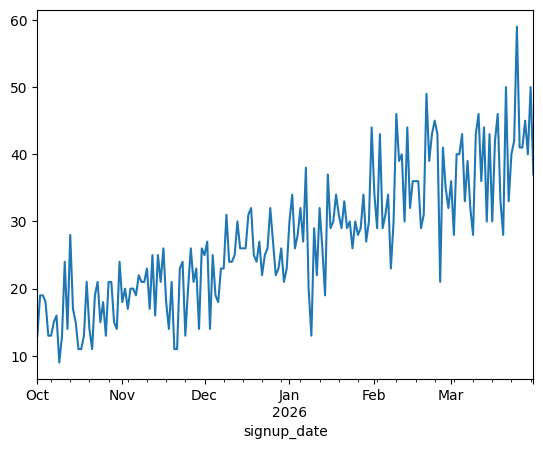

In [ ]:
users['signup_date'].value_counts().sort_index().plot()

In [ ]:
experiment_group = np.random.choice(
    ['control', 'treatment'],
    size=num_users,
    p=[0.5, 0.5]
)

In [ ]:
assignment_date = users['signup_date']

In [ ]:
experiment_assignments = pd.DataFrame({
    'user_id': users['user_id'],
    'experiment_group': experiment_group,
    'assignment_date': assignment_date
})

In [ ]:
experiment_assignments.head()

,user_id,experiment_group,assignment_date
0,1,treatment,2025-10-04
1,2,control,2025-10-19
2,3,control,2026-03-20
3,4,control,2026-03-04
4,5,treatment,2025-12-17


In [ ]:
experiment_assignments['experiment_group'].value_counts(normalize=True)

,proportion
experiment_group,
control,0.5064
treatment,0.4936


In [ ]:
users.merge(experiment_assignments, on='user_id').head()

,user_id,signup_date,country,device,experiment_group,assignment_date
0,1,2025-10-04,US,Desktop,treatment,2025-10-04
1,2,2025-10-19,UK,Mobile,control,2025-10-19
2,3,2026-03-20,IN,Mobile,control,2026-03-20
3,4,2026-03-04,US,Tablet,control,2026-03-04
4,5,2025-12-17,UK,Tablet,treatment,2025-12-17


In [ ]:
event_types = ['view', 'click', 'add_to_cart', 'purchase']

In [ ]:

np.random.seed(42)

activity_data = []

event_id = 1

for i in range(len(users)):
    user = users.iloc[i]
    user_id = user['user_id']
    signup_date = user['signup_date']

    group = experiment_assignments.iloc[i]['experiment_group']

    # Assign probabilities based on group
    if group == 'treatment':
        click_prob = 0.4
        cart_prob = 0.5
        purchase_prob = 0.3
    else:
        click_prob = 0.3
        cart_prob = 0.4
        purchase_prob = 0.2

    # Number of sessions per user
    n_sessions = np.random.randint(5, 21)

    for _ in range(n_sessions):

        # Random event time after signup
        event_time = signup_date + pd.to_timedelta(np.random.randint(0, 180), unit='d')

        product_id = np.random.randint(1, 1001)

        # VIEW event (always happens)
        activity_data.append([event_id, user_id, 'view', event_time, product_id, 0])
        event_id += 1

        # CLICK
        if np.random.rand() < click_prob:
            activity_data.append([event_id, user_id, 'click', event_time, product_id, 0])
            event_id += 1

            # ADD TO CART
            if np.random.rand() < cart_prob:
                activity_data.append([event_id, user_id, 'add_to_cart', event_time, product_id, 0])
                event_id += 1

                # PURCHASE
                if np.random.rand() < purchase_prob:
                    revenue = np.random.randint(500, 5000)
                    activity_data.append([event_id, user_id, 'purchase', event_time, product_id, revenue])
                    event_id += 1


# Create DataFrame
user_activity = pd.DataFrame(activity_data, columns=[
    'event_id', 'user_id', 'event_type', 'event_time', 'product_id', 'revenue'
])

In [ ]:
user_activity.head()

,event_id,user_id,event_type,event_time,product_id,revenue
0,1,1,view,2026-04-01,861,0
1,2,1,click,2026-04-01,861,0
2,3,1,view,2025-10-24,615,0
3,4,1,view,2025-12-17,459,0
4,5,1,view,2026-01-11,872,0


In [ ]:
user_activity['event_type'].value_counts()

,count
event_type,
view,63180
click,21988
add_to_cart,9983
purchase,2572


In [ ]:
user_activity[user_activity['event_type'] == 'purchase']['revenue'].describe()

,revenue
count,2572.000000
mean,2740.409020
std,1292.647648
min,500.000000
25%,1621.750000
50%,2714.000000
75%,3857.750000
max,4999.000000


In [ ]:
users.to_csv("users.csv", index=False)
experiment_assignments.to_csv("experiment_assignments.csv", index=False)
user_activity.to_csv("user_activity.csv", index=False)

SQL

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect(':memory:')

In [ ]:
users.to_sql('users', conn, index=False, if_exists='replace')
experiment_assignments.to_sql('experiment_assignments', conn, index=False, if_exists='replace')
user_activity.to_sql('user_activity', conn, index=False, if_exists='replace')

97723

In [ ]:
query = """
SELECT
    ea.experiment_group,
    COUNT(DISTINCT CASE WHEN ua.event_type = 'purchase' THEN ea.user_id END) AS purchasers,
    COUNT(DISTINCT ea.user_id) AS total_users,
    COUNT(DISTINCT CASE WHEN ua.event_type = 'purchase' THEN ea.user_id END) * 1.0
        / COUNT(DISTINCT ea.user_id) AS conversion_rate
FROM experiment_assignments ea
LEFT JOIN user_activity ua
    ON ea.user_id = ua.user_id
GROUP BY ea.experiment_group;
"""

result = pd.read_sql(query, conn)
result

,experiment_group,purchasers,total_users,conversion_rate
0,control,618,2532,0.244076
1,treatment,1276,2468,0.517018


In [ ]:
# Revenue Analysis: Measure business impact
query = """
SELECT
    ea.experiment_group,
    SUM(ua.revenue) AS total_revenue,
    SUM(ua.revenue) * 1.0 / COUNT(DISTINCT ea.user_id) AS revenue_per_user
FROM experiment_assignments ea
LEFT JOIN user_activity ua
    ON ea.user_id = ua.user_id
GROUP BY ea.experiment_group;
"""

result = pd.read_sql(query, conn)
result

,experiment_group,total_revenue,revenue_per_user
0,control,1932084,763.066351
1,treatment,5116248,2073.034036


In [ ]:
# Funnel Analysis: Measure business impact
query = """
SELECT
    event_type,
    ea.experiment_group,
    COUNT(*) as count
FROM user_activity ua
JOIN experiment_assignments ea
ON ua.user_id = ea.user_id
GROUP BY event_type, ea.experiment_group;
"""

result = pd.read_sql(query, conn)
result

,event_type,experiment_group,count
0,add_to_cart,control,3746
1,add_to_cart,treatment,6237
2,click,control,9507
3,click,treatment,12481
4,purchase,control,715
5,purchase,treatment,1857
6,view,control,32191
7,view,treatment,30989


In [ ]:
from google.colab import files

files.download("users.csv")
files.download("experiment_assignments.csv")
files.download("user_activity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>